## Imports

In [1]:
import lenstronomy

lenstronomy.__version__

'1.8.0'

In [2]:
import numpy as np
import os
import pickle
import copy
import time
import h5py
from pprint import pprint
import joblib
import gc
from tqdm import tnrange

import lenstronomy.Util.util as util
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Plots import chain_plot
from lenstronomy.Sampling.parameters import Param
from lenstronomy.Util import mask_util
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Data.coord_transforms import Coordinates
from lenstronomy.Util.util import array2image
from lenstronomy.Cosmo.lens_cosmo import LensCosmo

cwd = os.getcwd()
base_path, _ = os.path.split(cwd)
print('Base directory path:', base_path)

Base directory path: /Users/ajshajib/Research/time_delay_cosmography/J2038/WGD2038-4008/lenstronomy_modeling


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import paperfig as pf

pf.set_fontscale(2.)

import sys
sys.path.insert(0, './process_output')

from output_class import *
# to load the custom_log_likelihood function for unpickling

# Load output files

In [4]:
composite_files = [
    '2038_run145_1_0_0_0_0_shortened',
    '2038_run145_1_0_1_0_0_shortened',
    '2038_run145_1_0_2_0_0_shortened',
    '2038_run145_1_1_0_0_0_shortened',
    '2038_run145_1_1_1_0_0_shortened',
    '2038_run145_1_1_2_0_0_shortened',
    
    '2038_run146_1_0_0_0_0_shortened',
    '2038_run146_1_0_1_0_0_shortened',
    '2038_run146_1_0_2_0_0_shortened',
    '2038_run146_1_1_0_0_0_shortened',
    '2038_run146_1_1_1_0_0_shortened',
    '2038_run146_1_1_2_0_0_shortened',
]

In [5]:
composite_bics = []
composite_param_arrays = []
composite_num_param_arrays = []
composite_kwargs_models = []
composite_kwargs_constraints = []
composite_param_classes = []
composite_lens_models = []
composite_kwargs_likelihoods = []
composite_multi_band_list = []

for job_name_out in composite_files:
    output_temp = os.path.join(base_path, 'temp', job_name_out +'_out.txt')

    f = open(output_temp, 'rb')
    [input_, output_] = joblib.load(f)
    f.close()
    fitting_kwargs_list, kwargs_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, init_samples = input_
    kwargs_result, multi_band_list_out, fit_output, _ = output_
    multi_band_list = kwargs_joint['multi_band_list']

    samples_mcmc = fit_output[-1][1][np.random.randint(0, high=fit_output[-1][1].shape[0], size=10000)]
    param_mcmc = fit_output[-1][2]
    
    param_class = Param(kwargs_model,
                        kwargs_params['lens_model'][2], 
                        kwargs_params['source_model'][2],
                        kwargs_params['lens_light_model'][2],
                        kwargs_params['point_source_model'][2],
                        kwargs_lens_init=kwargs_params['lens_model'][0], #kwargs_result['kwargs_lens'],
                        **kwargs_constraints
                       )
    
    lens_model = LensModel(lens_model_list=kwargs_model['lens_model_list'],
                           z_lens=0.230, z_source=0.777,
                           multi_plane=False, #True, 
                          )
    
    num_data = np.sum([np.sum(m) for m in kwargs_likelihood['image_likelihood_mask_list']])
    num_param = param_class.num_param()[0] + param_class.num_param_linear()
    max_logL = np.max(fit_output[-1][-1])
    
    bic = compute_BIC(num_data, num_param, max_logL)
    
    composite_bics.append(bic)
    composite_param_arrays.append(np.copy(samples_mcmc))
    composite_num_param_arrays.append(len(samples_mcmc))
    composite_kwargs_models.append(kwargs_model)
    composite_kwargs_constraints.append(kwargs_constraints)
    composite_param_classes.append(param_class)
    composite_lens_models.append(lens_model)
    composite_kwargs_likelihoods.append(kwargs_likelihood)
    composite_multi_band_list.append(multi_band_list_out)
    
    gc.collect()
    #break

## Compute BIC weights and combine models

In [6]:
len(composite_kwargs_models)

12

In [7]:
# from the notebook "Fermat potentials and lens model comparisons"
sigma_numeric_bic, sigma_model_bic = 69.05339424569138, 237.25336211795366

In [8]:
num_sample = 1000

In [9]:
composite_r200s = []
composite_M200s = []
composite_c200s = []

lens_cosmo = LensCosmo(z_lens=0.230, z_source=0.777)

composite_weights = get_relative_weights(composite_bics, sigma_model_bic, take_std=False, 
                                  sigma_model=sigma_model_bic)    

for n_job in tnrange(len(composite_files), desc='Jobs:'):
    
    r200s, M200s, c200s = [], [], []
    
    num_sample_from_job = int(num_sample * composite_weights[n_job])
    
    sampled_indices = np.random.randint(low=0, high=composite_num_param_arrays[n_job], size=num_sample_from_job)
    
    lens_model = composite_lens_models[n_job] #lens_analysis.LensModel
    #lens_analysis = LensProfileAnalysis(composite_lens_models[n_job])
    
    for i in tnrange(len(sampled_indices), desc='Sample from job {:d}:'.format(n_job)): #len(samples_mcmc)):
        param_array = composite_param_arrays[n_job][sampled_indices[i]]

        param_class = composite_param_classes[n_job]
        
        kwargs_result = param_class.args2kwargs(param_array)
        lens_result = kwargs_result['kwargs_lens']
        lens_light_result = kwargs_result['kwargs_lens_light']
        source_result = kwargs_result['kwargs_source']
        ps_result = kwargs_result['kwargs_ps']

        _, _, c, r, M = lens_cosmo.nfw_angle2physical(lens_result[0]['Rs'], lens_result[0]['alpha_Rs'])
        
        r200s.append(r)
        M200s.append(M)
        c200s.append(c)
        

    composite_r200s += r200s
    composite_M200s += M200s
    composite_c200s += c200s

/Users/ajshajib/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`
  # Remove the CWD from sys.path while we load stuff.


Jobs::   0%|          | 0/12 [00:00<?, ?it/s]

/Users/ajshajib/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:21: TqdmDeprecationWarning: Please use `tqdm.notebook.trange` instead of `tqdm.tnrange`


Sample from job 0::   0%|          | 0/124 [00:00<?, ?it/s]

/Users/ajshajib/anaconda3/lib/python3.7/site-packages/scipy/optimize/minpack.py:162: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/ajshajib/anaconda3/lib/python3.7/site-packages/scipy/optimize/minpack.py:162: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


...

Sample from job 7::   0%|          | 0/855 [00:00<?, ?it/s]

Sample from job 8::   0%|          | 0/1000 [00:00<?, ?it/s]

Sample from job 9:: 0it [00:00, ?it/s]

Sample from job 10:: 0it [00:00, ?it/s]

Sample from job 11::   0%|          | 0/1 [00:00<?, ?it/s]

# Plot

/Users/ajshajib/Dropbox/PyCharm Projects/getdist/getdist/plots.py:10: MatplotlibDeprecationWarning: The 'warn' parameter of use() is deprecated since Matplotlib 3.1 and will be removed in 3.3.  If any parameter follows 'warn', they should be pass as keyword, not positionally.
  matplotlib.use('Agg', warn=False)


Cosmology "my_cosmo" 
    flat = True, Om0 = 0.3000, Ode0 = 0.6999, Ob0 = 0.0500, H0 = 70.00, sigma8 = 0.8230, ns = 0.9600
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False
Removed no burn in


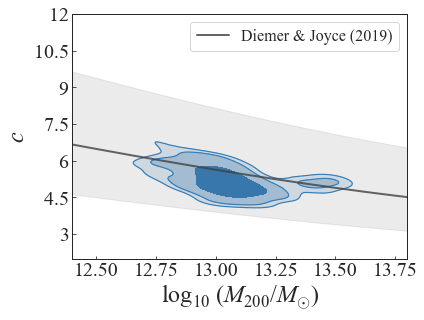

In [10]:
from colossus.cosmology import cosmology
from colossus.halo import concentration
from chainconsumer import ChainConsumer

from getdist import plots
from getdist import MCSamples

#cosmology.setCosmology('planck15');

#my_cosmo = {'flat': True, 'H0': 67.8, 'Om0': 0.3, 'Ob0': 0.05, 'sigma8': 0.823, 'ns': 0.96} # cosmo to match with Behroozi et al. 2019
my_cosmo = {'flat': True, 'H0': 70., 'Om0': 0.3, 'Ob0': 0.05, 'sigma8': 0.823, 'ns': 0.96} # fiducial cosmo
my_cosmo = cosmology.setCosmology('my_cosmo', my_cosmo)

print(my_cosmo)
#print(cosmo)

z_l = 0.23
z_s = 0.777

#rho0, Rs, c, r200, M200 = lens_cosmo.nfw_angle2physical(samples_mcmc[:, 4], samples_mcmc[:, 5])

Ms = np.logspace(12., 14.6, 200)
c200_th = concentration.concentration(Ms*my_cosmo.h, '200c', z_l, model='diemer19')

mc_samples = MCSamples(samples=[np.log10(composite_M200s).flatten(), 
                                np.squeeze(composite_c200s).flatten()], 
                       names=['M200', 'c200'], 
                       labels=['\\log_{10} (M_{200}/M_{\odot})', 'c_{200}'])
mc_samples.updateSettings({'smooth_scale_2D': 2})

g = plots.getSinglePlotter()
#mc_samples.updateSettings({'contours': [0.3934693, 0.8646647, 0.9888910, 0.9996645, 0.9999963]})
mc_samples.updateSettings({'contours': [0.68, 0.95, 0.99]})

g.settings.num_plot_contours = 3
g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 24

g.plot_2d(mc_samples, 'M200', 'c200', shaded=False, filled=True,
          line_args=[{'ls':'-', 'color': pf.cb_blue}]
         );

ax = g.fig.gca()

# g.fig.tight_layout()

ax.plot(np.log10(Ms), c200_th, color=pf.cb_grey, label='Diemer & Joyce (2019)', alpha=0.8, lw=2)
ax.fill_between(np.log10(Ms), 10**(np.log10(c200_th)+0.16), 10**(np.log10(c200_th)-0.16), alpha=0.1,  
                 color=pf.cb_grey)


    
ax.set_xlabel(r'$\log_{10}\ (M_{200}/M_{\odot})$')
ax.set_xlim(12.4, 13.8)
ax.set_ylim(2, 12)
ax.set_ylabel(r'$c$')
#ax.set_title('Central deflector\'s $M$-$c$ relation')
ax.legend()

g.fig.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/m_c_relation.pdf', bbox_inches='tight')

g.fig